<a href="https://colab.research.google.com/github/Aaditya-Ranjan/CV-Mini-Projects/blob/main/Unit_2_shape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Shape Recognition using Boundary Descriptors and Image Moments(unit2)**







Dataset Name:Four Shapes Dataset (Kaggle)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("smeschke/four-shapes")
print("Dataset downloaded to:", path)


100%|██████████| 21.6M/21.6M [00:00<00:00, 151MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    break


/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2


In [ ]:
import os

for root, dirs, files in os.walk("/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2"):
    print(root, dirs[:5], files[:5])


/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2 ['shapes'] ['display_model.py', 'process_data.py', 'make_model.py']
/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes ['circle', 'triangle', 'square', 'star'] []
/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/circle [] ['3576.png', '2055.png', '277.png', '1529.png', '1666.png']
/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/triangle [] ['3576.png', '2055.png', '277.png', '1529.png', '1666.png']
/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/square [] ['3576.png', '2055.png', '277.png', '1529.png', '1666.png']
/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/star [] ['3576.png', '2055.png', '277.png', '1529.png', '1666.png']


In [ ]:
import glob

path = "/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes"
image_paths = glob.glob(path + "/*/*.png")

print("Total images:", len(image_paths))
image_paths[:5]


Total images: 14970


['/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/circle/3576.png',
 '/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/circle/2055.png',
 '/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/circle/277.png',
 '/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/circle/1529.png',
 '/root/.cache/kagglehub/datasets/smeschke/four-shapes/versions/2/shapes/circle/1666.png']

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

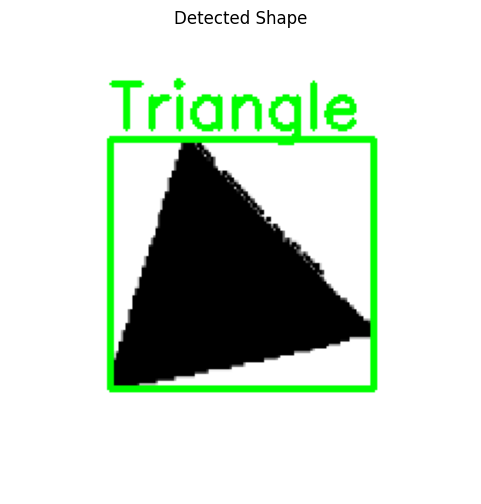

In [ ]:
  import cv2, numpy as np, matplotlib.pyplot as plt, random

  img = cv2.imread(random.choice(image_paths))
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # preprocessing
  blur = cv2.GaussianBlur(gray, (5,5), 0)
  _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

  contours,_ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  out = img.copy()

  def classify(cnt):
      area = cv2.contourArea(cnt)
      if area < 200: return None

      peri = cv2.arcLength(cnt, True)
      approx = cv2.approxPolyDP(cnt, 0.02*peri, True)
      v = len(approx)

      # star / spiky shape check (low solidity)
      hull = cv2.convexHull(cnt)
      solidity = area / (cv2.contourArea(hull) + 1e-6)

      # Hu Moments for circle confirmation
      hu = cv2.HuMoments(cv2.moments(cnt)).flatten()
      hu0 = abs(hu[0])

      # circularity
      circularity = (4*np.pi*area) / (peri*peri + 1e-6)

      # bounding box ratio
      x,y,w,h = cv2.boundingRect(cnt)
      ar = w/float(h)

      # ---- RULES ----
      if v == 3:
          return "Triangle"

      if v == 4:
          return "Square" if 0.90 <= ar <= 1.10 else "Rectangle"

      # circle check (Hu moment & circularity)
      if circularity > 0.78 and hu0 < 0.002:
          return "Circle"

      # star check (lots of points + low solidity)
      if v >= 8 and solidity < 0.95:
          return "Star"

      return "Polygon"

  for c in contours:
      shape = classify(c)
      if not shape: continue
      x,y,w,h = cv2.boundingRect(c)
      cv2.rectangle(out,(x,y),(x+w,y+h),(0,255,0),2)
      cv2.putText(out, shape, (x,y-5), cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2)

  plt.figure(figsize=(6,6))
  plt.title("Detected Shape")
  plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
  plt.axis("off")
